# Push-T V2 inference

This notebook loads the V2 checkpoints from diffuser/models/V2, runs a Push-T rollout, and renders the behavior as plots and a GIF.

V2 corresponds to ResNet-18 ImageNet fine-tune. Select the Python (.venv_diffuser_infer) kernel before running the code cells.

In [10]:
from IPython.display import Image, display
import matplotlib.pyplot as plt

from v2_inference_utils import (
    MODEL_DIR,
    compare_checkpoints,
    default_checkpoint,
    list_checkpoints,
    plot_checkpoint_comparison,
    plot_rollout,
    resolve_device,
    run_rollout,
    save_gif,
)

device = resolve_device()
checkpoints = list_checkpoints(MODEL_DIR)
print('Device:', device)
print('Checkpoints:')
for checkpoint in checkpoints:
    print(' -', checkpoint.name)

Device: cuda:0
Checkpoints:
 - epoch=0150-test_mean_score=0.648.ckpt
 - epoch=0200-test_mean_score=0.549.ckpt
 - epoch=0250-test_mean_score=0.559.ckpt
 - latest.ckpt


{'checkpoint': 'epoch=0150-test_mean_score=0.648.ckpt', 'seed': 10049, 'device': 'cuda:0', 'env_steps': 300, 'decision_steps': 38, 'max_reward': 0.8818, 'success': False}


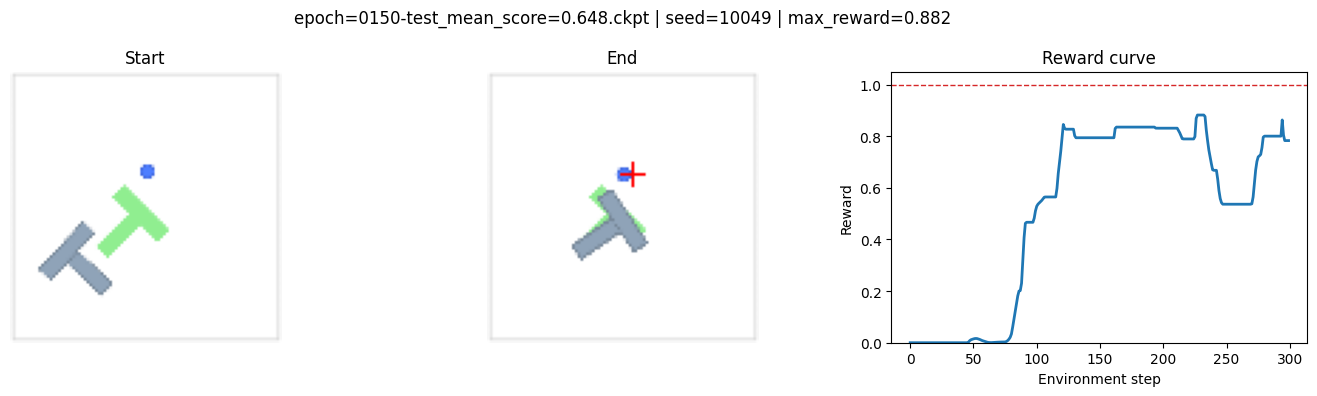

In [17]:
checkpoint_path = default_checkpoint()
seed = 10049
result = run_rollout(checkpoint_path=checkpoint_path, seed=seed, device=device)
print({
    'checkpoint': result['checkpoint_name'],
    'seed': result['seed'],
    'device': result['device'],
    'env_steps': result['n_env_steps'],
    'decision_steps': result['n_decisions'],
    'max_reward': round(result['max_reward'], 4),
    'success': result['success'],
})
fig = plot_rollout(result)
plt.show()

In [18]:
gif_path = save_gif(result, fps=5)
gif_path

WindowsPath('C:/Users/moise/Documents/0001_MADI/TFM/diffuser/artifacts/v0_inference/gifs/epoch_0150-test_mean_score_0.648_seed10049.gif')

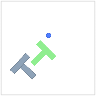

In [20]:
display(Image(filename=str(gif_path)))

c:\Users\moise\Documents\0001_MADI\TFM\.venv_diffuser_infer\Lib\site-packages\shapely\set_operations.py:131: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
c:\Users\moise\Documents\0001_MADI\TFM\.venv_diffuser_infer\Lib\site-packages\shapely\set_operations.py:131: RuntimeWarning: divide by zero encountered in intersection
  return lib.intersection(a, b, **kwargs)


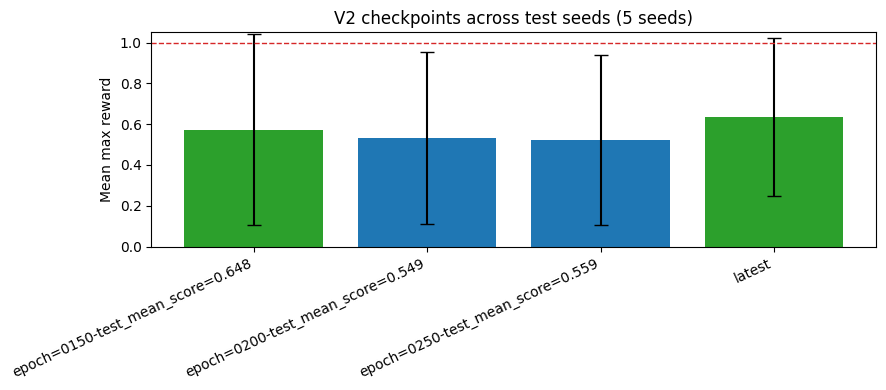

In [16]:
import importlib

import v0_inference_utils

import v2_inference_utils



importlib.reload(v0_inference_utils)

v2_inference_utils = importlib.reload(v2_inference_utils)



# Subset fijo del rango oficial de test 100000-100049.

# Los scores de entrenamiento usan las 50 seeds; esta celda es una estimación rápida.

evaluation_seeds = [100000, 100010, 100020, 100030, 100040]

comparison = v2_inference_utils.compare_checkpoints(

    seeds=evaluation_seeds,

    device=device,

)

comparison

fig = v2_inference_utils.plot_checkpoint_comparison(comparison)

plt.show()